In [92]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [84]:
import tensorflow as tf
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Combine training and test data
X_full = np.concatenate((x_train, x_test), axis=0)
y_full = np.concatenate((y_train, y_test), axis=0)

# Select 5000 random samples to match the original dataset size mentioned in the output
num_samples = 5000
random_indices = np.random.choice(X_full.shape[0], num_samples, replace=False)
X_subset = X_full[random_indices]
y_subset = y_full[random_indices]

# Flatten the images from (num_samples, 28, 28) to (num_samples, 784)
# No resizing to 20x20, maintaining original 28x28 resolution
X = X_subset.reshape(num_samples, -1)

# Normalize pixel values to be between 0 and 1
X = X / 255.0

# Reshape y to (num_samples, 1)
y = y_subset.reshape(-1, 1)

print(f"Shape of X after preprocessing: {X.shape}")
print(f"Shape of y after preprocessing: {y.shape}")

Shape of X after preprocessing: (5000, 784)
Shape of y after preprocessing: (5000, 1)


In [85]:
print(X[0])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [86]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  5


In [87]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (5000, 784)
The shape of y is: (5000, 1)


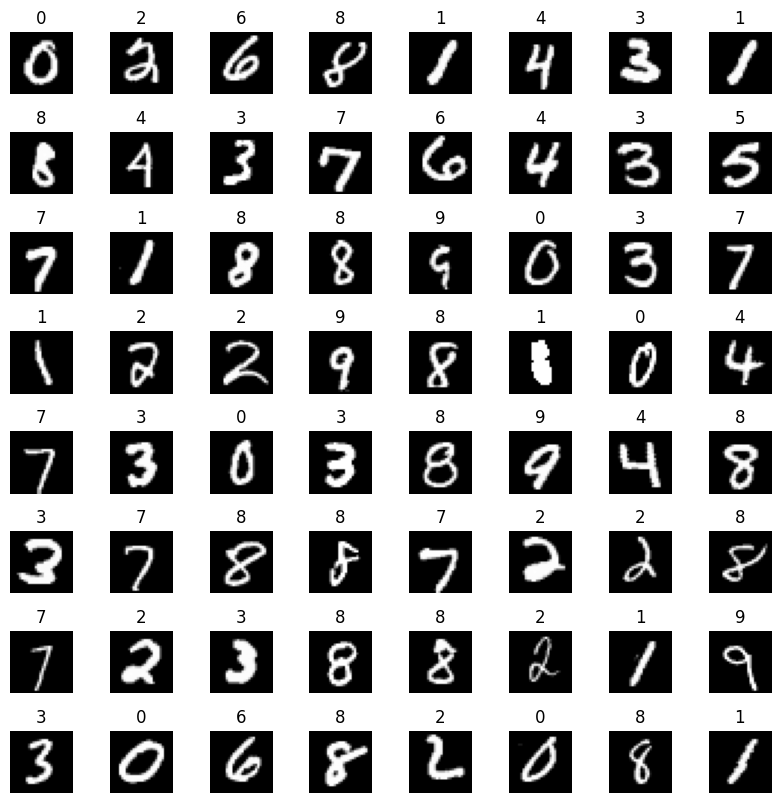

In [88]:
m,n=X.shape

fig,axes=plt.subplots(8,8,figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
  random_index=np.random.randint(m)
  x_random_reshaped=X[random_index].reshape((28,28)) # Updated reshape to 28x28

  ax.imshow(x_random_reshaped,cmap='gray')
  ax.set_title(y[random_index,0])
  ax.set_axis_off()

In [89]:
model=Sequential([
    # Convolution Layer 1
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    # Pooling Layer 1
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 2
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    # Pooling Layer 2
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Convert 2D feature maps to 1D
    tf.keras.layers.Flatten(),
    Dense(128,activation='relu'), # Increased neurons from 25 to 128
    Dense(10,activation='linear') # Output layer for 10 classes
],name='Model'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [90]:
model.summary()

Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
conv1_layer, pool1_layer, conv2_layer, pool2_layer, flatten_layer, dense1_layer, dense2_layer = model.layers

In [98]:
from sklearn.metrics import recall_score, f1_score, accuracy_score

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.001), # Reduced learning rate from 0.01 to 0.001
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')
    ]
)

# Reshape X to (num_samples, 28, 28, 1) for the CNN model
X_reshaped = X.reshape(-1, 28, 28, 1)

history = model.fit(
    X_reshaped,y,
    epochs=20
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.8274 - loss: 0.5649
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9538 - loss: 0.1524
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9698 - loss: 0.0950
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9828 - loss: 0.0607
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9826 - loss: 0.0516
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9896 - loss: 0.0340
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9906 - loss: 0.0278
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9956 - loss: 0.0162
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9930 - loss: 0.0216
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9948 - loss: 0.0173
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9968 - loss: 0.0112
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 

In [99]:
import numpy as np

# Reshape X[0] from (784,) to (1, 28, 28, 1) for CNN input
prediction_input_0 = X[0].reshape(1, 28, 28, 1)
prediction = model.predict(prediction_input_0)
print(f"predicting a zero: {tf.nn.softmax(prediction)}")

# Reshape X[500] from (784,) to (1, 28, 28, 1) for CNN input
prediction_input_500 = X[500].reshape(1, 28, 28, 1)
prediction = model.predict(prediction_input_500)
print(f"predicting a one:  {tf.nn.softmax(prediction)}")

# Extract weights and biases from the new dense layers and convolutional layers
# For dense1_layer
w_dense1, b_dense1 = dense1_layer.get_weights()
print(f"\nWeights and Biases for Dense Layer 1:")
print(f"  Shape of w_dense1: {w_dense1.shape}")
print(f"  Shape of b_dense1: {b_dense1.shape}")

# For dense2_layer (output layer)
w_dense2, b_dense2 = dense2_layer.get_weights()
print(f"\nWeights and Biases for Dense Layer 2 (Output):")
print(f"  Shape of w_dense2: {w_dense2.shape}")
print(f"  Shape of b_dense2: {b_dense2.shape}")

# If you also want to inspect convolutional layer weights:
w_conv1, b_conv1 = conv1_layer.get_weights()
print(f"\nWeights and Biases for Convolutional Layer 1:")
print(f"  Shape of w_conv1: {w_conv1.shape}")
print(f"  Shape of b_conv1: {b_conv1.shape}")

w_conv2, b_conv2 = conv2_layer.get_weights()
print(f"\nWeights and Biases for Convolutional Layer 2:")
print(f"  Shape of w_conv2: {w_conv2.shape}")
print(f"  Shape of b_conv2: {b_conv2.shape}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
predicting a zero: [[2.3105671e-13 1.0000000e+00 1.0803624e-09 9.6232844e-10 1.1875965e-09
  2.4522924e-13 7.5391559e-13 6.4538019e-12 1.8627204e-11 6.5635228e-14]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
predicting a one:  [[9.9999845e-01 4.0859026e-13 1.3723430e-07 5.3889136e-11 3.6849066e-08
  5.4118961e-14 1.4362231e-06 7.4280247e-13 1.1073575e-08 2.5228755e-09]]

Weights and Biases for Dense Layer 1:
  Shape of w_dense1: (1600, 128)
  Shape of b_dense1: (128,)

Weights and Biases for Dense Layer 2 (Output):
  Shape of w_dense2: (128, 10)
  Shape of b_dense2: (10,)

Weights and Biases for Convolutional Layer 1:
  Shape of w_conv1: (3, 3, 1, 32)
  Shape of b_conv1: (32,)

Weights and Biases for Convolutional Layer 2:
  Shape of w_conv2: (3, 3, 32, 64)
  Shape of b_conv2: (64,)


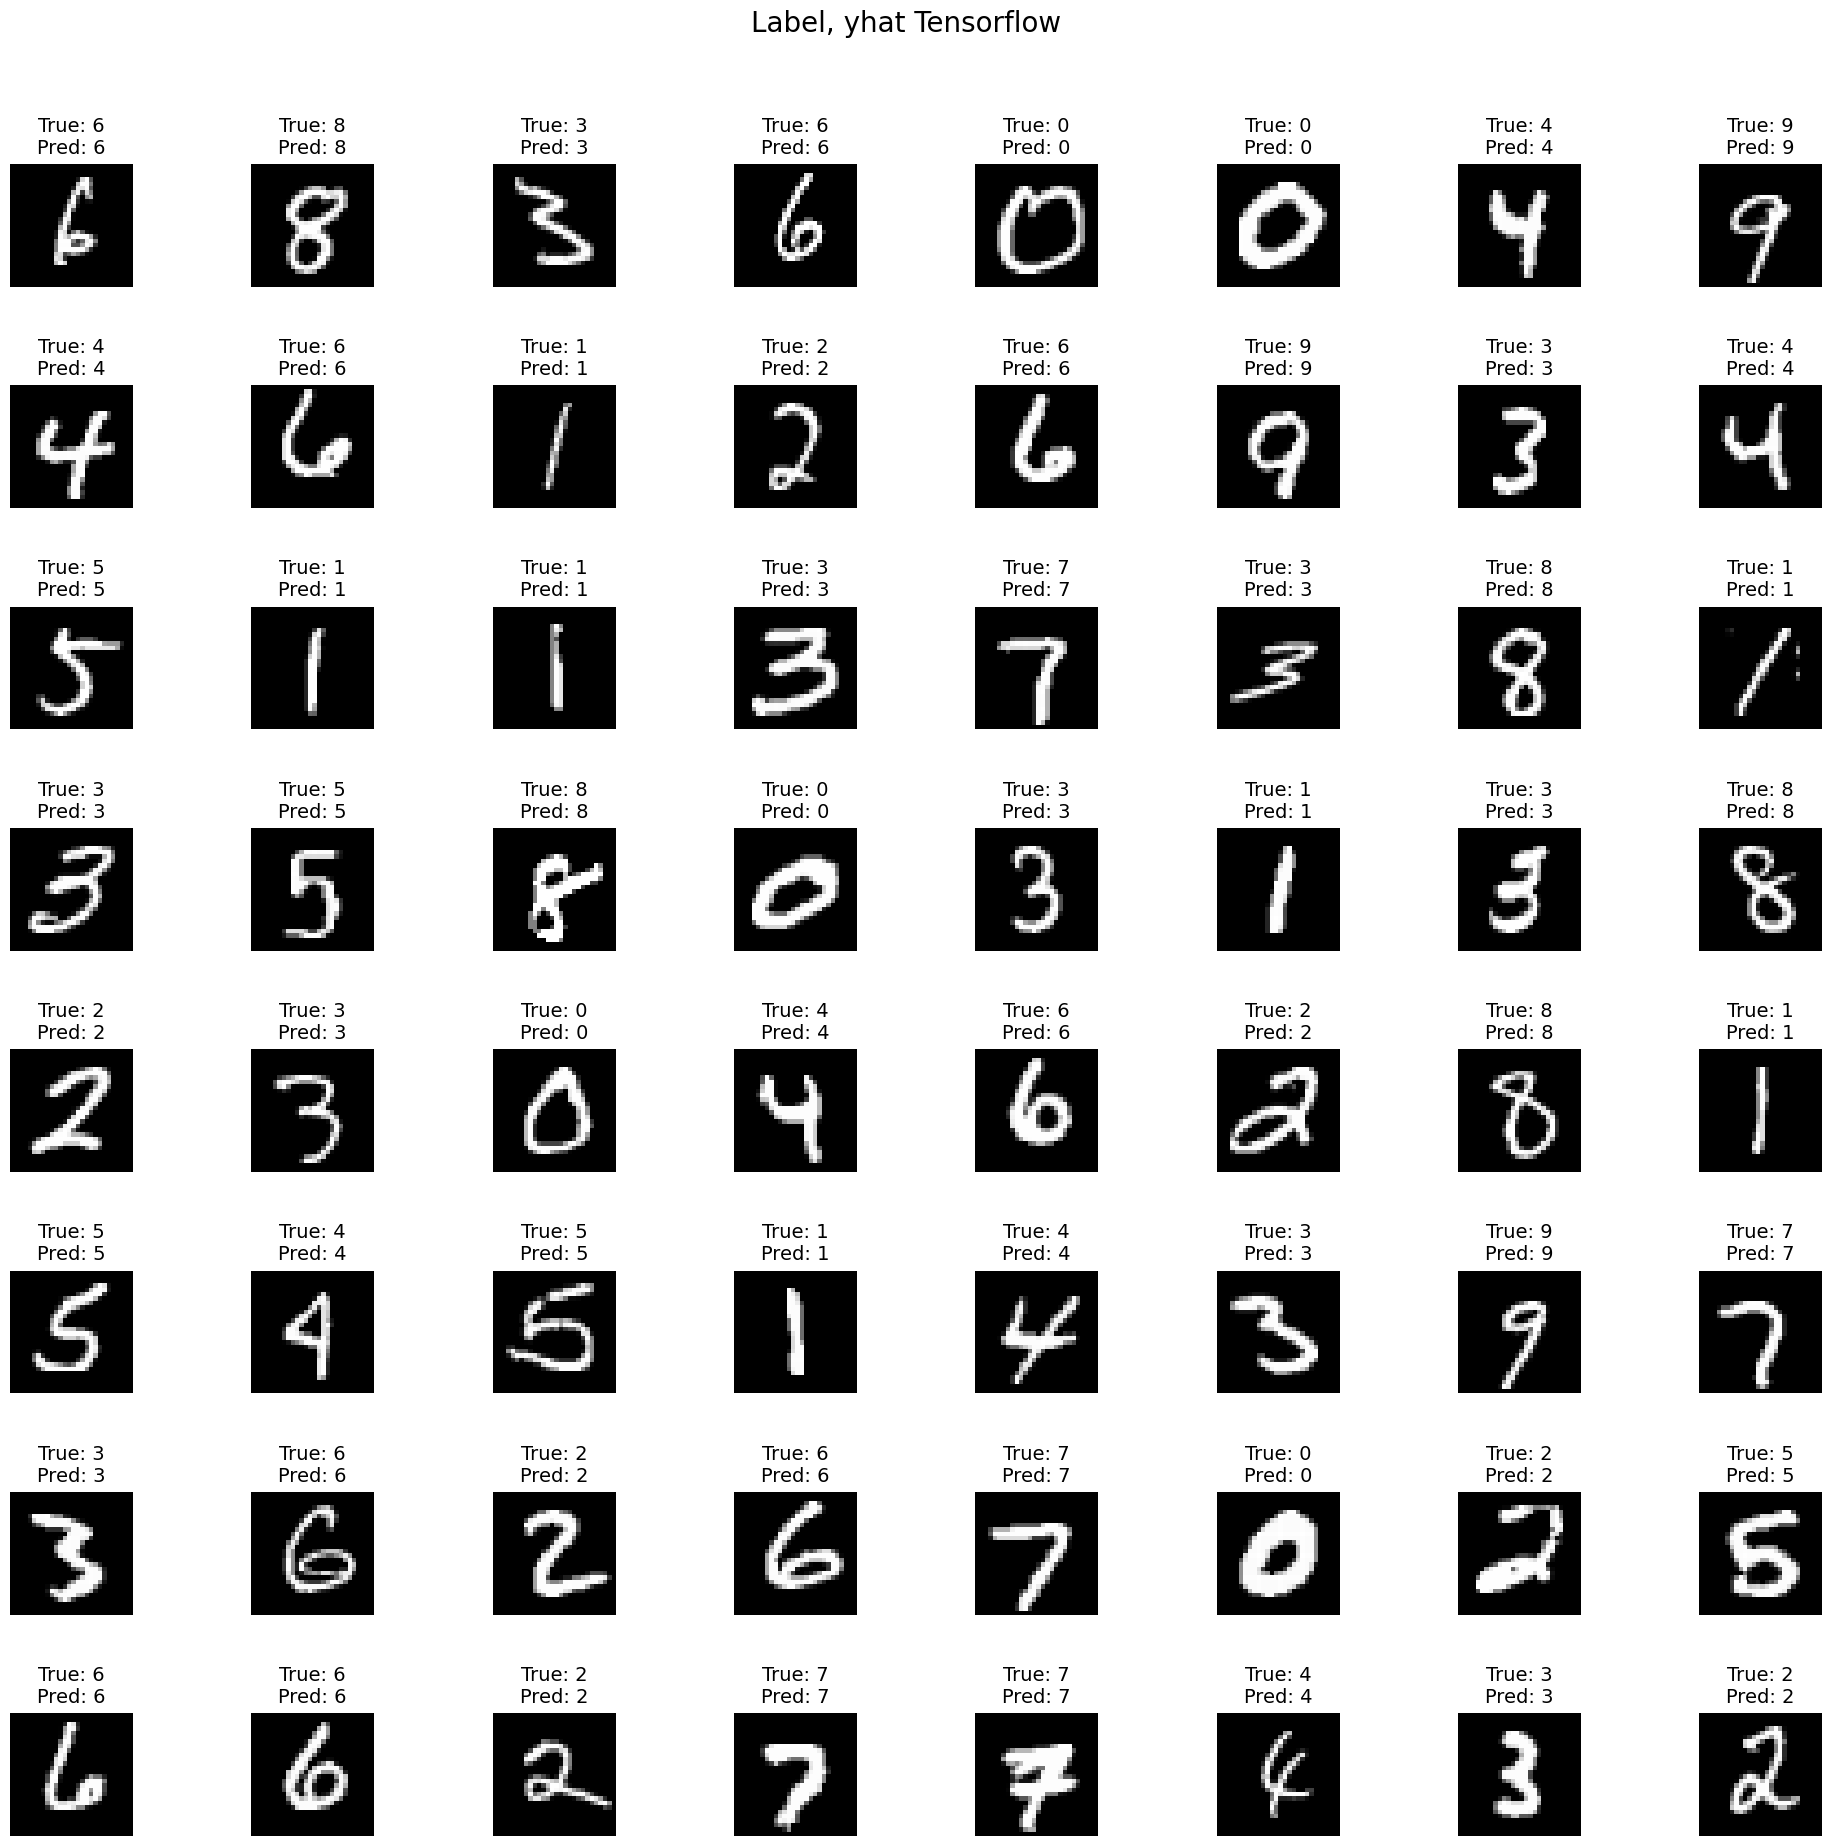

In [100]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --- Start of included data loading and preprocessing (from cell 7f203cc7) ---
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Combine training and test data
X_full = np.concatenate((x_train, x_test), axis=0)
y_full = np.concatenate((y_train, y_test), axis=0)

# Select 5000 random samples to match the original dataset size mentioned in the output
num_samples = 5000
random_indices = np.random.choice(X_full.shape[0], num_samples, replace=False)
X_subset = X_full[random_indices]
y_subset = y_full[random_indices]

# Flatten the images from (num_samples, 28, 28) to (num_samples, 784)
# No resizing to 20x20, maintaining original 28x28 resolution
X = X_subset.reshape(num_samples, -1)

# Normalize pixel values to be between 0 and 1
X = X / 255.0

# Reshape y to (num_samples, 1)
y = y_subset.reshape(-1, 1)
# --- End of included data loading and preprocessing ---

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(20,20))   # bigger canvas
fig.tight_layout(pad=5, rect=[0, 0.03, 1, 0.95])

for i, ax in enumerate(axes.flat):

    random_index = np.random.randint(m)

    X_random_reshaped = X[random_index].reshape((28,28)) # Updated reshape to 28x28
    ax.imshow(X_random_reshaped, cmap='gray')

    tf_prediction = model.predict(
        X[random_index].reshape(1, 28, 28, 1), # Changed reshape to 4D for CNN input
        verbose=0
    )

    tf_yhat = tf.nn.softmax(tf_prediction)
    tf_predicted_label = np.argmax(tf_yhat)

    ax.set_title(
        f"True: {y[random_index,0]}\nPred: {tf_predicted_label}",  # split into 2 lines
        fontsize=14,
        pad=8                      # space between image and title
    )

    ax.axis("off")

fig.suptitle(
    "Label, yhat Tensorflow",
    fontsize=20,
    y=0.99                        # move main title upward
)

plt.show()

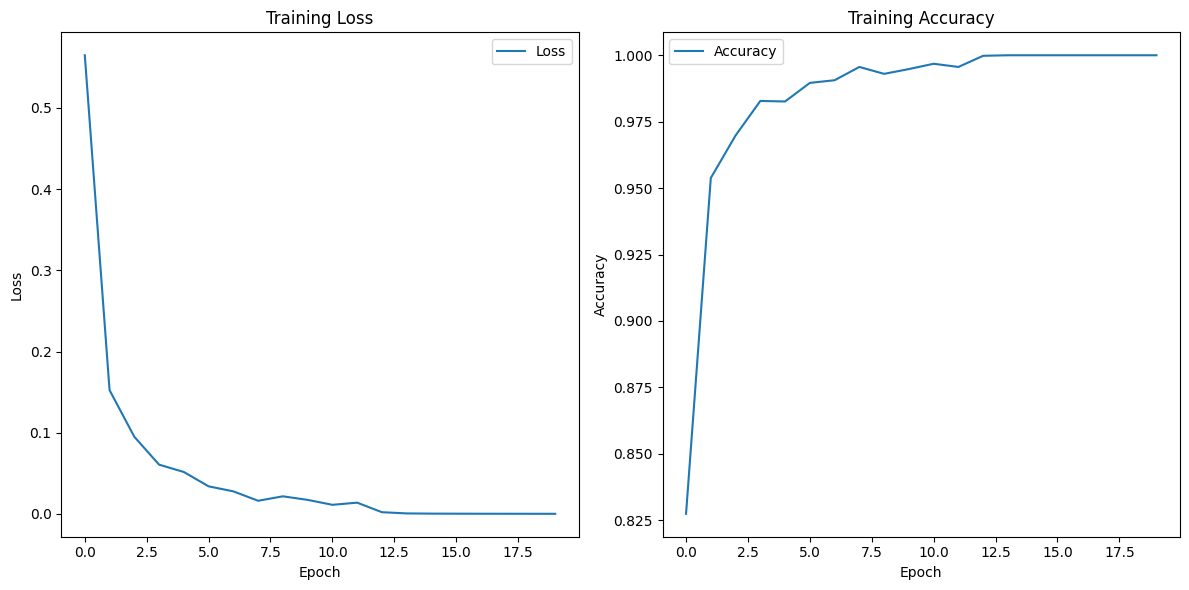

In [102]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 6)) # Adjusted figsize for 2 plots

# Plot Loss
plt.subplot(1, 2, 1) # Changed to 1 row, 2 columns
plt.plot(history.history['loss'], label='Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2) # Changed to 1 row, 2 columns
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Precision, Recall, and F1-score are not available per epoch in 'history.history' for multi-class
# These metrics were calculated and visualized in subsequent cells using sklearn.metrics.

plt.tight_layout()
plt.show()


### Confusion Matrix Analysis

To further evaluate the model's performance and identify specific misclassifications, we will compute and visualize the confusion matrix. This matrix provides a detailed breakdown of correct and incorrect predictions for each class.

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step
Confusion Matrix:
[[461   0   1   0   0   1   2   0   1   0]
 [  0 556   5   0   0   0   1   3   2   0]
 [  0   0 513   2   0   0   0   5   2   0]
 [  0   0   5 517   0   3   0   3   3   0]
 [  0   0   1   0 472   0   0   0   1   2]
 [  1   1   0   1   0 444   0   0   4   2]
 [  2   1   0   0   2   4 483   0   3   0]
 [  1   0   5   0   1   0   0 510   2   4]
 [  1   1   2   0   4   1   3   1 434   1]
 [  1   1   1   1   3   1   0   9   2 500]]


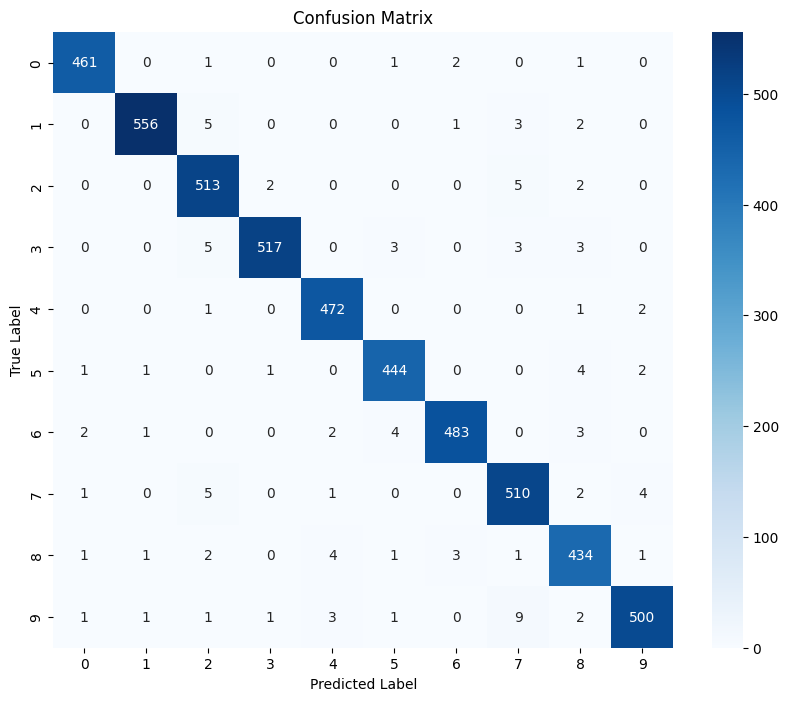

In [104]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Reshape X to (num_samples, 28, 28, 1) for the CNN model prediction
X_predict_reshaped = X.reshape(-1, 28, 28, 1)

# Get predictions for the entire dataset X
y_pred_raw = model.predict(X_predict_reshaped)
# Convert logits to probabilities and then to predicted class labels
y_pred = np.argmax(tf.nn.softmax(y_pred_raw), axis=1)

# Flatten the true labels y
y_true = y.flatten()

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
print('Confusion Matrix:')
print(cm)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [105]:
model.save("handwritten_digits.keras")

In [106]:
from google.colab import files
files.download("handwritten_digits.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>